# GAMIC

In [1]:
import xarray as xr
from open_radar_data import DATASETS

import xradar as xd

## Download

Fetching GAMIC radar data file from [open-radar-data](https://github.com/openradar/open-radar-data) repository.

In [2]:
filename = DATASETS.fetch("DWD-Vol-2_99999_20180601054047_00.h5")

## xr.open_dataset

Making use of the xarray `gamic` backend. We also need to provide the group. Note, that we are using CfRadial2 group access pattern.

In [3]:
ds = xr.open_dataset(filename, group="sweep_9", engine="gamic")
display(ds)

C:\Users\egoud\.venvs\wradlib\Lib\site-packages\xarray\backends\plugins.py:110: RuntimeWarning: Engine 'radolan' loading failed:
module 'wradlib.georef.raster' has no attribute 'read_gdal_values'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


<xarray.Dataset> Size: 17MB
Dimensions:            (azimuth: 360, range: 1000)
Coordinates:
  * azimuth            (azimuth) float64 3kB 0.5109 1.519 2.519 ... 358.5 359.5
    elevation          (azimuth) float64 3kB ...
    time               (azimuth) datetime64[ns] 3kB ...
  * range              (range) float32 4kB 75.0 225.0 ... 1.498e+05 1.499e+05
    longitude          float64 8B ...
    latitude           float64 8B ...
    altitude           float64 8B ...
Data variables: (12/18)
    DBZH               (azimuth, range) float32 1MB ...
    DBZV               (azimuth, range) float32 1MB ...
    KDP                (azimuth, range) float32 1MB ...
    RHOHV              (azimuth, range) float32 1MB ...
    DBTH               (azimuth, range) float32 1MB ...
    DBTV               (azimuth, range) float32 1MB ...
    ...                 ...
    sweep_mode         <U20 80B ...
    sweep_number       int64 8B ...
    prt_mode           <U7 28B ...
    follow_mode        <U7 28B ...
    sweep_fixed_angle  float64 8B ...
    nyquist_velocity   float64 8B ...
Attributes:
    source:         gamic
    ant_gain_h:     43
    ant_gain_v:     43
    noise_power_h:  -3.40133
    noise_power_v:  -3.13518
    rx_loss_h:      3
    rx_loss_v:      3

### Plot Time vs. Azimuth

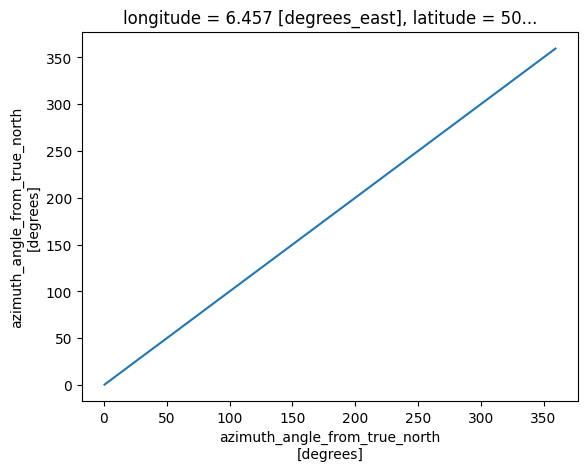

In [4]:
ds.azimuth.plot()

### Plot Range vs. Time

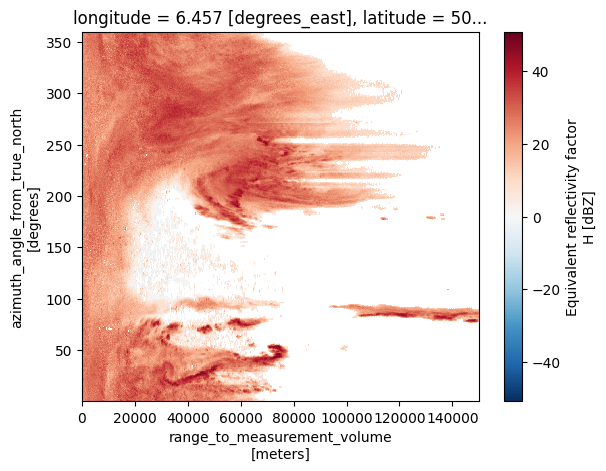

In [5]:
ds.DBZH.plot()

### Plot Range vs. Azimuth

We need to sort by azimuth and specify the y-coordinate.

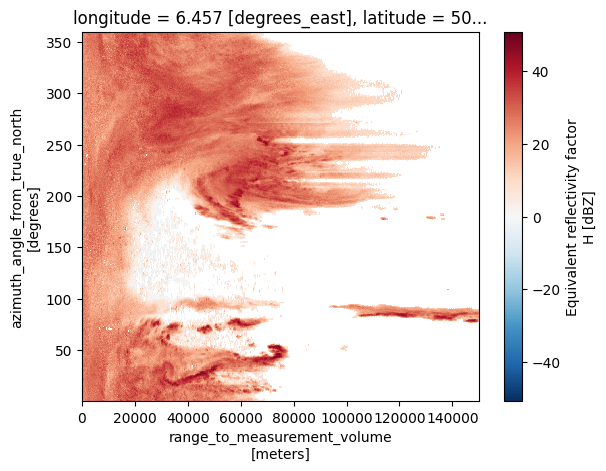

In [6]:
ds.DBZH.sortby("azimuth").plot(y="azimuth")

## backend_kwargs

Beside `first_dim` there are several additional backend_kwargs for the odim backend, which handle different aspects of angle alignment. This comes into play, when azimuth and/or elevation arrays are not evenly spacend and other issues.

In [7]:
help(xd.io.GamicBackendEntrypoint)

Help on class GamicBackendEntrypoint in module xradar.io.backends.gamic:

class GamicBackendEntrypoint(xarray.backends.common.BackendEntrypoint)
 |  Xarray BackendEntrypoint for GAMIC data.
 |
 |  Keyword Arguments
 |  -----------------
 |  first_dim : str
 |      Can be ``time`` or ``auto`` first dimension. If set to ``auto``,
 |      first dimension will be either ``azimuth`` or ``elevation`` depending on
 |      type of sweep. Defaults to ``auto``.
 |  reindex_angle : bool or dict
 |      Defaults to False, no reindexing. Given dict should contain the kwargs to
 |      reindex_angle. Only invoked if `decode_coord=True`.
 |  fix_second_angle : bool
 |      For PPI only. If True, fixes erroneous second angle data. Defaults to ``False``.
 |  site_coords : bool
 |      Attach radar site-coordinates to Dataset, defaults to ``True``.
 |  kwargs : dict
 |      Additional kwargs are fed to :py:func:`xarray.open_dataset`.
 |
 |  Method resolution order:
 |      GamicBackendEntrypoint
 |     

In [8]:
ds = xr.open_dataset(filename, group="sweep_9", engine="gamic", first_dim="time")
display(ds)

<xarray.Dataset> Size: 17MB
Dimensions:            (time: 360, range: 1000)
Coordinates:
    azimuth            (time) float64 3kB ...
    elevation          (time) float64 3kB ...
  * time               (time) datetime64[ns] 3kB 2018-06-01T05:43:40.504000 ....
  * range              (range) float32 4kB 75.0 225.0 ... 1.498e+05 1.499e+05
    longitude          float64 8B ...
    latitude           float64 8B ...
    altitude           float64 8B ...
Data variables: (12/18)
    DBZH               (time, range) float32 1MB ...
    DBZV               (time, range) float32 1MB ...
    KDP                (time, range) float32 1MB ...
    RHOHV              (time, range) float32 1MB ...
    DBTH               (time, range) float32 1MB ...
    DBTV               (time, range) float32 1MB ...
    ...                 ...
    sweep_mode         <U20 80B ...
    sweep_number       int64 8B ...
    prt_mode           <U7 28B ...
    follow_mode        <U7 28B ...
    sweep_fixed_angle  float64 8B ...
    nyquist_velocity   float64 8B ...
Attributes:
    source:         gamic
    ant_gain_h:     43
    ant_gain_v:     43
    noise_power_h:  -3.40133
    noise_power_v:  -3.13518
    rx_loss_h:      3
    rx_loss_v:      3

## open_odim_datatree

The same works analoguous with the datatree loader. But additionally we can provide a sweep string, number or list.

In [9]:
help(xd.io.open_gamic_datatree)

Help on function open_gamic_datatree in module xradar.io.backends.gamic:

open_gamic_datatree(filename_or_obj, **kwargs)
    Open GAMIC HDF5 dataset as :py:class:`xarray.DataTree`.

    Parameters
    ----------
    filename_or_obj : str, Path, file-like or DataStore
        Strings and Path objects are interpreted as a path to a local or remote
        radar file

    Keyword Arguments
    -----------------
    sweep : int, list of int, optional
        Sweep number(s) to extract, default to first sweep. If None, all sweeps are
        extracted into a list.
    first_dim : str
        Can be ``time`` or ``auto`` first dimension. If set to ``auto``,
        first dimension will be either ``azimuth`` or ``elevation`` depending on
        type of sweep. Defaults to ``auto``.
    reindex_angle : bool or dict
        Defaults to False, no reindexing. Given dict should contain the kwargs to
        reindex_angle. Only invoked if `decode_coord=True`.
    fix_second_angle : bool
        If T

In [10]:
dtree = xd.io.open_gamic_datatree(filename, sweep=8)
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 1)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2018-06-01T05:43:08Z'
│       time_coverage_end    <U20 80B '2018-06-01T05:43:38Z'
│       longitude            float64 8B 6.457
│       altitude             float64 8B 310.0
│       latitude             float64 8B 50.93
│       sweep_group_name     (sweep) int64 8B 8
│       sweep_fixed_angle    (sweep) float64 8B 1.7
│   Attributes:
│       Conventions:      None
│       instrument_name:  None
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           gamic
│       history:          None
│       comment:          im/exported using xradar
├── Group: /sweep_0
│       Dimensions:            (azimuth: 360, range: 1000)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 0.5191 1.516 2.516 ... 358.5 359.5
│           elevation          (azimuth) float64 3kB ...
│           time               (azimuth) datetime64[ns] 3kB 2018-06-01T05:43:17.69900...
│         * range              (range) float32 4kB 75.0 225.0 ... 1.498e+05 1.499e+05
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables: (12/18)
│           DBZH               (azimuth, range) float32 1MB ...
│           DBZV               (azimuth, range) float32 1MB ...
│           KDP                (azimuth, range) float32 1MB ...
│           RHOHV              (azimuth, range) float32 1MB ...
│           DBTH               (azimuth, range) float32 1MB ...
│           DBTV               (azimuth, range) float32 1MB ...
│           ...                 ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
│           nyquist_velocity   float64 8B ...
├── Group: /radar_parameters
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B ...
│           latitude   float64 8B ...
│           altitude   float64 8B ...
├── Group: /georeferencing_correction
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B ...
│           latitude   float64 8B ...
│           altitude   float64 8B ...
└── Group: /radar_calibration
        Dimensions:        ()
        Data variables:
            ant_gain_v     <U2 8B '43'
            rx_loss_h      <U1 4B '3'
            rx_loss_v      <U1 4B '3'
            ant_gain_h     <U2 8B '43'
            noise_power_h  <U7 28B '-3.8298'
            noise_power_v  <U7 28B '-3.5802'

### Plot Sweep Range vs. Time

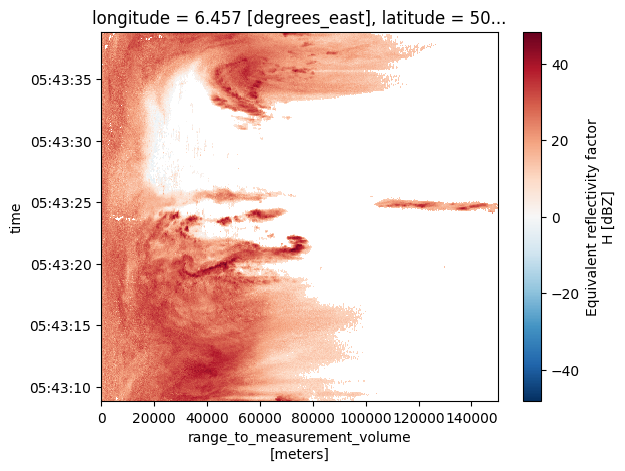

In [11]:
dtree["sweep_0"].ds.DBZH.sortby("time").plot(y="time")

### Plot Sweep Range vs. Azimuth

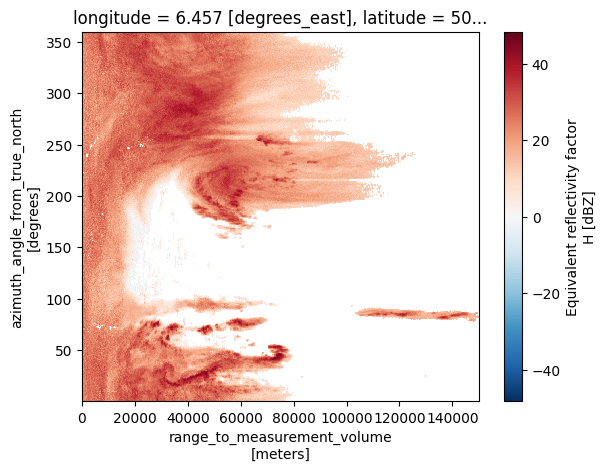

In [12]:
dtree["sweep_0"].ds.DBZH.plot()

In [13]:
dtree = xd.io.open_gamic_datatree(filename, sweep="sweep_8")
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 1)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2018-06-01T05:43:08Z'
│       time_coverage_end    <U20 80B '2018-06-01T05:43:38Z'
│       longitude            float64 8B 6.457
│       altitude             float64 8B 310.0
│       latitude             float64 8B 50.93
│       sweep_group_name     (sweep) int64 8B 8
│       sweep_fixed_angle    (sweep) float64 8B 1.7
│   Attributes:
│       Conventions:      None
│       instrument_name:  None
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           gamic
│       history:          None
│       comment:          im/exported using xradar
├── Group: /sweep_0
│       Dimensions:            (azimuth: 360, range: 1000)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 0.5191 1.516 2.516 ... 358.5 359.5
│           elevation          (azimuth) float64 3kB ...
│           time               (azimuth) datetime64[ns] 3kB 2018-06-01T05:43:17.69900...
│         * range              (range) float32 4kB 75.0 225.0 ... 1.498e+05 1.499e+05
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables: (12/18)
│           DBZH               (azimuth, range) float32 1MB ...
│           DBZV               (azimuth, range) float32 1MB ...
│           KDP                (azimuth, range) float32 1MB ...
│           RHOHV              (azimuth, range) float32 1MB ...
│           DBTH               (azimuth, range) float32 1MB ...
│           DBTV               (azimuth, range) float32 1MB ...
│           ...                 ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
│           nyquist_velocity   float64 8B ...
├── Group: /radar_parameters
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B ...
│           latitude   float64 8B ...
│           altitude   float64 8B ...
├── Group: /georeferencing_correction
│       Dimensions:    ()
│       Coordinates:
│           longitude  float64 8B ...
│           latitude   float64 8B ...
│           altitude   float64 8B ...
└── Group: /radar_calibration
        Dimensions:        ()
        Data variables:
            ant_gain_v     <U2 8B '43'
            rx_loss_h      <U1 4B '3'
            rx_loss_v      <U1 4B '3'
            ant_gain_h     <U2 8B '43'
            noise_power_h  <U7 28B '-3.8298'
            noise_power_v  <U7 28B '-3.5802'

In [14]:
dtree = xd.io.open_gamic_datatree(filename, sweep=[0, 1, 8])
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 3)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2018-06-01T05:40:47Z'
│       time_coverage_end    <U20 80B '2018-06-01T05:43:38Z'
│       longitude            float64 8B 6.457
│       altitude             float64 8B 310.0
│       latitude             float64 8B 50.93
│       sweep_group_name     (sweep) int64 24B 0 1 8
│       sweep_fixed_angle    (sweep) float64 24B 28.0 18.0 1.7
│   Attributes:
│       Conventions:      None
│       instrument_name:  None
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           gamic
│       history:          None
│       comment:          im/exported using xradar
├── Group: /sweep_0
│       Dimensions:            (azimuth: 361, range: 360)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 0.5219 1.519 2.53 ... 358.5 359.5
│           elevation          (azimuth) float64 3kB ...
│           time               (azimuth) datetime64[ns] 3kB 2018-06-01T05:40:57.36300...
│         * range              (range) float32 1kB 50.0 150.0 ... 3.585e+04 3.595e+04
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables: (12/18)
│           DBZH               (azimuth, range) float32 520kB ...
│           DBZV               (azimuth, range) float32 520kB ...
│           KDP                (azimuth, range) float32 520kB ...
│           RHOHV              (azimuth, range) float32 520kB ...
│           DBTH               (azimuth, range) float32 520kB ...
│           DBTV               (azimuth, range) float32 520kB ...
│           ...                 ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
│           nyquist_velocity   float64 8B ...
├── Group: /sweep_1
│       Dimensions:            (azimuth: 361, range: 500)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 0.5246 1.533 2.543 ... 358.5 359.5
│           elevation          (azimuth) float64 3kB ...
│           time               (azimuth) datetime64[ns] 3kB 2018-06-01T05:41:10.99700...
│         * range              (range) float32 2kB 50.0 150.0 ... 4.985e+04 4.995e+04
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables: (12/18)
│           DBZH               (azimuth, range) float32 722kB ...
│           DBZV               (azimuth, range) float32 722kB ...
│           KDP                (azimuth, range) float32 722kB ...
│           RHOHV              (azimuth, range) float32 722kB ...
│           DBTH               (azimuth, range) float32 722kB ...
│           DBTV               (azimuth, range) float32 722kB ...
│           ...                 ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
│           nyquist_velocity   float64 8B ...
├── Group: /sweep_2
│       Dimensions:            (azimuth: 360, range: 1000)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 0.5191 1.516 2.516 ... 358.5 359.5
│           elevation          (azimuth) float64 3kB ...
│           time               (azimuth) datetime64[ns] 3kB 2018-06-01T05:43:17.69900...
│         * range              (range) float32 4kB 75.0 225.0 ... 1.498e+05 1.499e+05
│           longitude          float64 8B ...
│         

In [15]:
dtree = xd.io.open_gamic_datatree(filename, sweep=["sweep_1", "sweep_2", "sweep_8"])
display(dtree)

<xarray.DataTree>
Group: /
│   Dimensions:              (sweep: 3)
│   Dimensions without coordinates: sweep
│   Data variables:
│       volume_number        int64 8B 0
│       platform_type        <U5 20B 'fixed'
│       instrument_type      <U5 20B 'radar'
│       time_coverage_start  <U20 80B '2018-06-01T05:41:01Z'
│       time_coverage_end    <U20 80B '2018-06-01T05:43:38Z'
│       longitude            float64 8B 6.457
│       altitude             float64 8B 310.0
│       latitude             float64 8B 50.93
│       sweep_group_name     (sweep) int64 24B 1 2 8
│       sweep_fixed_angle    (sweep) float64 24B 18.0 14.0 1.7
│   Attributes:
│       Conventions:      None
│       instrument_name:  None
│       version:          None
│       title:            None
│       institution:      None
│       references:       None
│       source:           gamic
│       history:          None
│       comment:          im/exported using xradar
├── Group: /sweep_0
│       Dimensions:            (azimuth: 361, range: 500)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 0.5246 1.533 2.543 ... 358.5 359.5
│           elevation          (azimuth) float64 3kB ...
│           time               (azimuth) datetime64[ns] 3kB 2018-06-01T05:41:10.99700...
│         * range              (range) float32 2kB 50.0 150.0 ... 4.985e+04 4.995e+04
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables: (12/18)
│           DBZH               (azimuth, range) float32 722kB ...
│           DBZV               (azimuth, range) float32 722kB ...
│           KDP                (azimuth, range) float32 722kB ...
│           RHOHV              (azimuth, range) float32 722kB ...
│           DBTH               (azimuth, range) float32 722kB ...
│           DBTV               (azimuth, range) float32 722kB ...
│           ...                 ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
│           nyquist_velocity   float64 8B ...
├── Group: /sweep_1
│       Dimensions:            (azimuth: 361, range: 620)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 0.5191 1.524 2.527 ... 358.5 359.5
│           elevation          (azimuth) float64 3kB ...
│           time               (azimuth) datetime64[ns] 3kB 2018-06-01T05:41:24.84300...
│         * range              (range) float32 2kB 50.0 150.0 ... 6.185e+04 6.195e+04
│           longitude          float64 8B ...
│           latitude           float64 8B ...
│           altitude           float64 8B ...
│       Data variables: (12/18)
│           DBZH               (azimuth, range) float32 895kB ...
│           DBZV               (azimuth, range) float32 895kB ...
│           KDP                (azimuth, range) float32 895kB ...
│           RHOHV              (azimuth, range) float32 895kB ...
│           DBTH               (azimuth, range) float32 895kB ...
│           DBTV               (azimuth, range) float32 895kB ...
│           ...                 ...
│           sweep_mode         <U20 80B ...
│           sweep_number       int64 8B ...
│           prt_mode           <U7 28B ...
│           follow_mode        <U7 28B ...
│           sweep_fixed_angle  float64 8B ...
│           nyquist_velocity   float64 8B ...
├── Group: /sweep_2
│       Dimensions:            (azimuth: 360, range: 1000)
│       Coordinates:
│         * azimuth            (azimuth) float64 3kB 0.5191 1.516 2.516 ... 358.5 359.5
│           elevation          (azimuth) float64 3kB ...
│           time               (azimuth) datetime64[ns] 3kB 2018-06-01T05:43:17.69900...
│         * range              (range) float32 4kB 75.0 225.0 ... 1.498e+05 1.499e+05
│           longitude          float64 8B ...
│        